# Problem Statement 
The real estate industry often needs accurate estimation of property prices based on various house characteristics. In this task, the goal is to build a Machine Learning regression model that predicts the price of a house using features such as house size, number of bedrooms, number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was built.

# Objective 
The objective of this task is to:
* Understand and explore the housing dataset.
* Perform data preprocessing including handling missing values, duplicates, and outliers.
* Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the data.
* Apply encoding, log transformation, and feature scaling where necessary.
* Train multiple regression algorithms to predict house prices.
* Evaluate and compare model performance using appropriate evaluation metrics.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading dataset

In [8]:
data = pd.read_csv("house_price_regression_dataset.csv")
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [9]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [10]:
data.isnull().sum() # There is no missing values

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [11]:
data.duplicated().sum() # There are no Duplicate values

np.int64(0)

# Exploratory Data Analysis

###  Univariate Analysis 

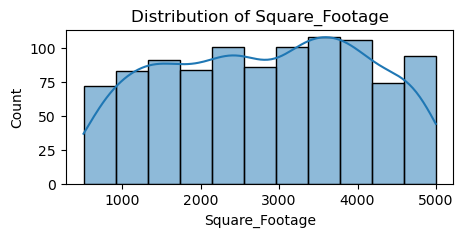

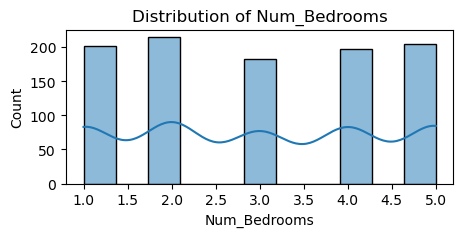

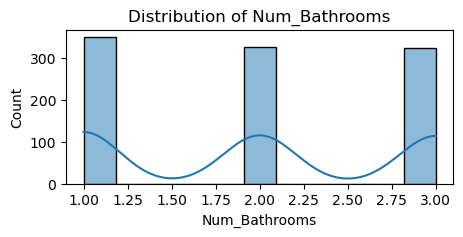

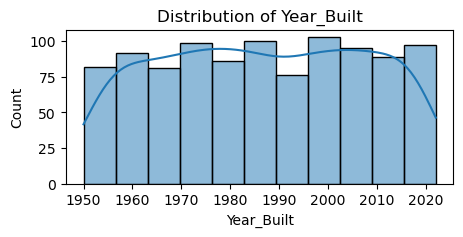

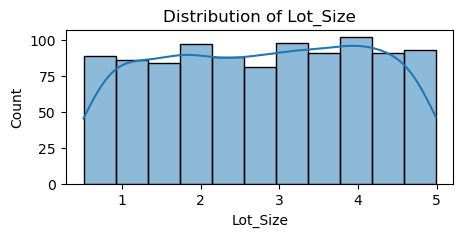

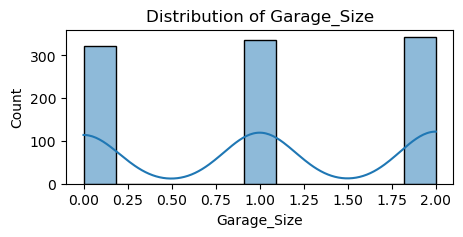

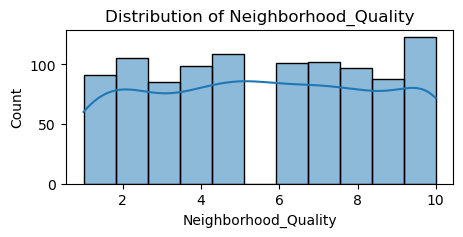

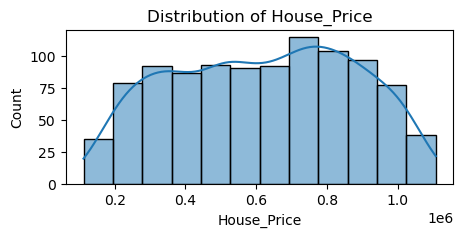

In [18]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.histplot(data[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

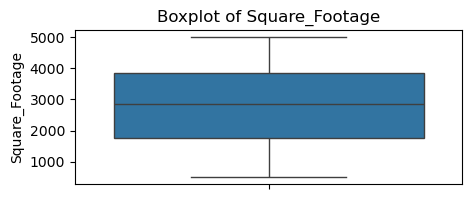

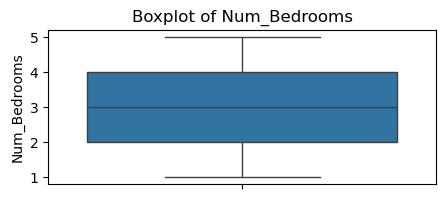

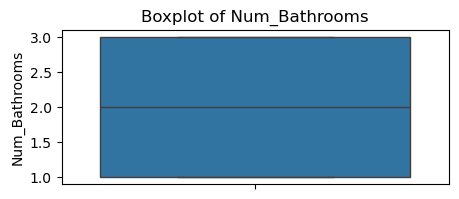

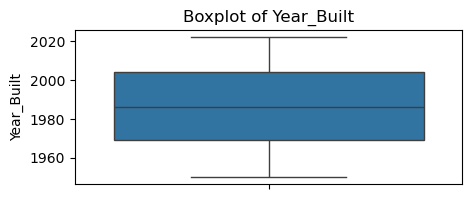

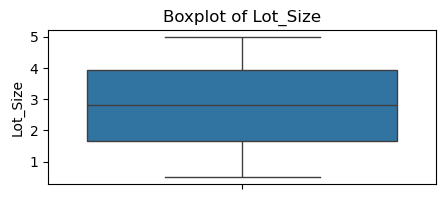

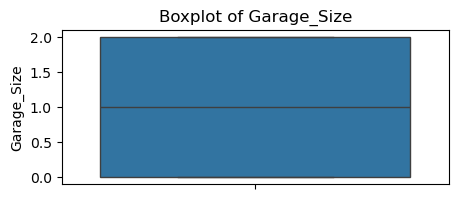

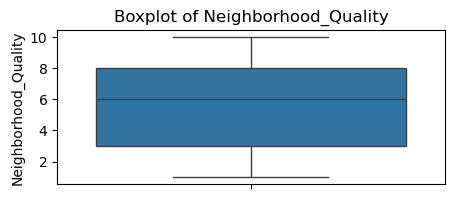

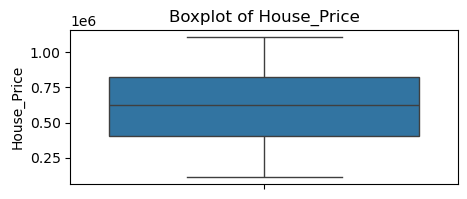

In [37]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Bivariate Analysis 

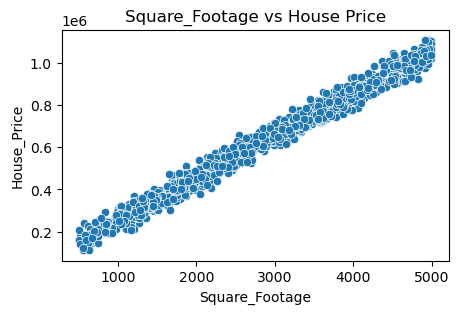

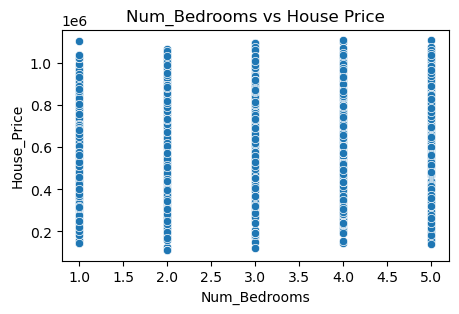

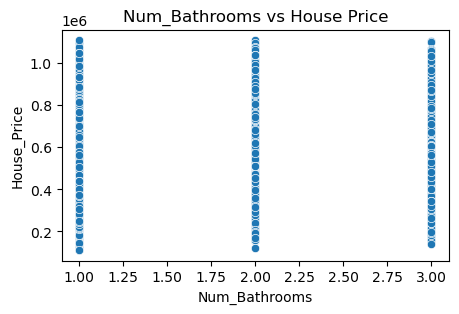

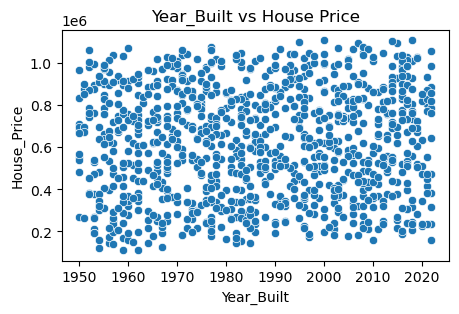

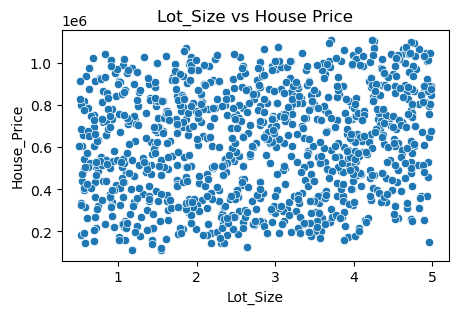

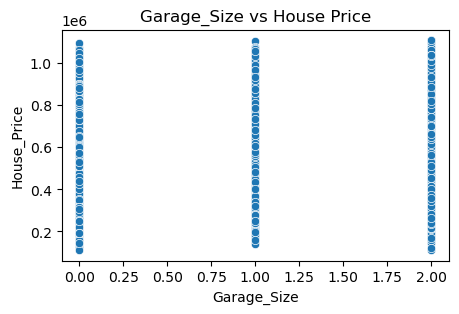

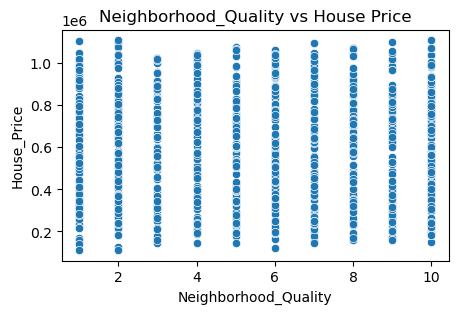

In [25]:
target = "House_Price"
for col in num_cols:
    if col!=target:
        plt.figure(figsize=(5,3))
        sns.scatterplot(x=data[col],y=data[target])
        plt.title(f'{col} vs House Price')
        plt.show()

### Correlation Heatmap

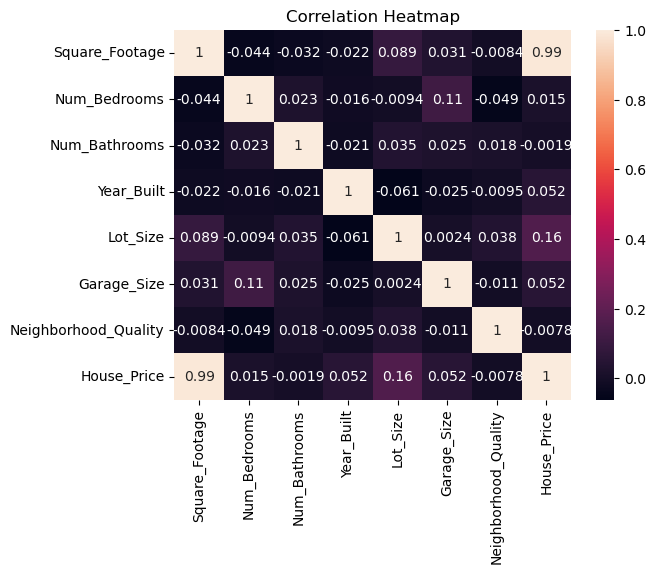

In [31]:
sns.heatmap(data.corr(), annot=True,)
plt.title("Correlation Heatmap")
plt.show()

### Detecting Outlier

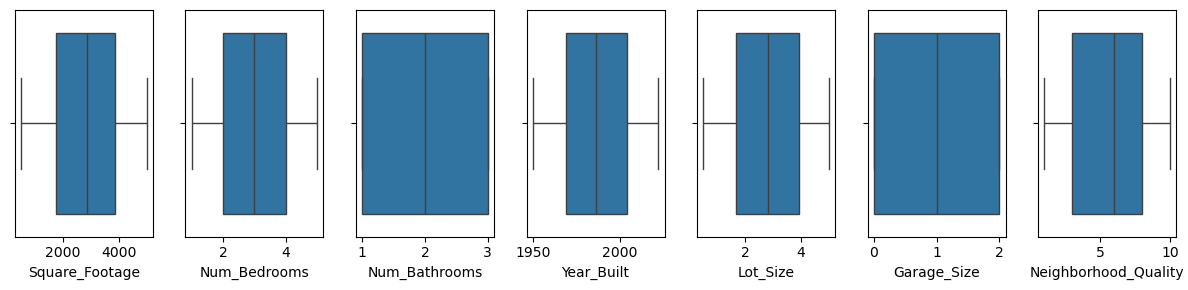

In [35]:

fig,ax=plt.subplots(1,7,figsize=(12,3))
sns.boxplot(data,x='Square_Footage',ax=ax[0])
sns.boxplot(data,x='Num_Bedrooms',ax=ax[1])
sns.boxplot(data,x='Num_Bathrooms',ax=ax[2])
sns.boxplot(data,x='Year_Built',ax=ax[3])
sns.boxplot(data,x='Lot_Size',ax=ax[4])
sns.boxplot(data,x='Garage_Size',ax=ax[5])
sns.boxplot(data,x='Neighborhood_Quality',ax=ax[6])
plt.tight_layout()

##### Hence No Outliers

In [39]:
#Log Transformation 
data['House_Price'] = np.log(data['House_Price'])

In [46]:
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,12.477560
1,4272,3,3,2016,4.753014,1,6,13.800662
2,3592,1,2,2016,3.634823,0,9,13.564453
3,966,1,2,1977,2.730667,1,8,12.344525
4,4926,2,1,1993,4.699073,0,8,13.856404


# Split data for X and Y

In [50]:
X = data.drop(columns=['House_Price'])
y = data.loc[:,'House_Price']

# Split data for training and testing

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Feature Scalling

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Linear Regression

In [59]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)


LinearRegression()

In [71]:
y_pred_lr = lr.predict(X_test)

In [72]:
y_test_actual = np.exp(y_test)
y_pred_lr_actual = np.exp(y_pred_lr)

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression Performance:")
print("MAE:", mean_absolute_error(y_test_actual, y_pred_lr_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_lr_actual)))
print("R2 Score:", r2_score(y_test_actual, y_pred_lr_actual))

Linear Regression Performance:
MAE: 51521.834283573386
RMSE: 66971.51499297895
R2 Score: 0.930417881681397


###### *The Linear Regression model explains 93% of the variance in house prices (R² = 0.93), showing strong predictive performance.*

### KNN

In [74]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [75]:
y_pred_knn = knn.predict(X_test)

In [76]:
y_pred_knn_actual = np.exp(y_pred_knn)

In [77]:
print("KNN Regression Performance:")
print("MAE:", mean_absolute_error(y_test_actual, y_pred_knn_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_knn_actual)))
print("R2 Score:", r2_score(y_test_actual, y_pred_knn_actual))

KNN Regression Performance:
MAE: 69627.51929316013
RMSE: 82897.68453805799
R2 Score: 0.8933889551814408


###### *The KNN Regression model achieved an R² score of 0.89, indicating 89% accuracy*.

In [ ]:
# Linear Regression outperformed KNN with higher R² score and lower error values.
# Hence, Linear Regression is selected as the best model for predicting house prices.